# lcbinint / VBM light-curve comparison

This notebook uses the public `LightCurve` callable API.  The callable keeps numerical options and limb darkening fixed; fitted parameters stay as named call arguments.

In [1]:
from dataclasses import dataclass
import time

import matplotlib.pyplot as plt
import numpy as np

import lcbinint

try:
    import VBMicrolensing
except ImportError:
    VBMicrolensing = None

In [9]:
@dataclass(frozen=True)
class Case:
    s: float = 0.95
    q: float = 1.0e-2
    t0: float = 0.0
    tE: float = 1.0
    u0: float = -1.0e-3
    alpha: float = 0.5
    rho: float = 1.0e-2
    t_min: float = -0.8
    t_max: float = 0.8
    n_times: int = 400

case = Case()
times = np.linspace(case.t_min, case.t_max, case.n_times)

options = lcbinint.Options(coordinates="vbm", source_bins=50, max_source_bins=400, reltol=1.0e-3)
lightcurve = lcbinint.LightCurve(
    lens="binary_lens",
    options=options,
    limb_darkening=lcbinint.LimbDarkening.linear(0.5),
)

In [10]:
def lcbinint_curve(limb_darkening):
    curve = lcbinint.LightCurve(
        lens="binary_lens",
        options=options,
        limb_darkening=limb_darkening,
    )
    curve(
        times,
        t0=case.t0,
        tE=case.tE,
        u0=case.u0,
        alpha=case.alpha,
        s=case.s,
        q=case.q,
        rho=case.rho,
    )
    t_start = time.perf_counter()
    mag = np.asarray(curve(
        times,
        t0=case.t0,
        tE=case.tE,
        u0=case.u0,
        alpha=case.alpha,
        s=case.s,
        q=case.q,
        rho=case.rho,
    ))
    ms = 1.0e3 * (time.perf_counter() - t_start) / times.size
    return curve, mag, ms


def vbm_curve(limb_darkening_gamma):
    if VBMicrolensing is None:
        return np.full_like(times, np.nan), np.nan

    vbm = VBMicrolensing.VBMicrolensing()
    vbm.Tol = 1.0e-3
    vbm.a1 = limb_darkening_gamma
    vbm.a2 = 0.0
    params = [np.log(case.s), np.log(case.q), case.u0, case.alpha, np.log(case.rho), np.log(case.tE), case.t0]
    vbm.BinaryLightCurve(params, times.tolist())
    t_start = time.perf_counter()
    mag = np.asarray(vbm.BinaryLightCurve(params, times.tolist())[0])
    ms = 1.0e3 * (time.perf_counter() - t_start) / times.size
    return mag, ms


def relative_error(reference, values):
    return np.abs(values - reference) / np.maximum(np.abs(reference), 1.0e-12)


def print_error(label, reference, values):
    rel = relative_error(reference, values)
    print(
        f"{label:5s} relative error: "
        f"max={np.max(rel):.3e}, p99={np.percentile(rel, 99):.3e}, "
        f"median={np.median(rel):.3e}, rms={np.sqrt(np.mean(rel * rel)):.3e}"
    )


lightcurve, lc_no_ld, lc_no_ld_ms = lcbinint_curve(lcbinint.LimbDarkening.none())
_, lc_ld, lc_ld_ms = lcbinint_curve(lcbinint.LimbDarkening.linear(0.5))
vbm_no_ld, vbm_no_ld_ms = vbm_curve(0.0)
vbm_ld, vbm_ld_ms = vbm_curve(0.5)

print("ms/point")
print(f"  lcbinint no LD: {lc_no_ld_ms:.4f}")
print(f"  lcbinint LD   : {lc_ld_ms:.4f}")
print(f"  VBM no LD     : {vbm_no_ld_ms:.4f}")
print(f"  VBM LD        : {vbm_ld_ms:.4f}")
if np.all(np.isfinite(vbm_no_ld)):
    print_error("no LD", vbm_no_ld, lc_no_ld)
    print_error("LD", vbm_ld, lc_ld)


ms/point
  lcbinint no LD: 2.0632
  lcbinint LD   : 2.2427
  VBM no LD     : 0.0863
  VBM LD        : 2.0102
no LD relative error: max=7.223e-04, p99=4.764e-04, median=2.230e-05, rms=9.862e-05
LD    relative error: max=4.917e-04, p99=3.238e-04, median=2.518e-05, rms=7.024e-05


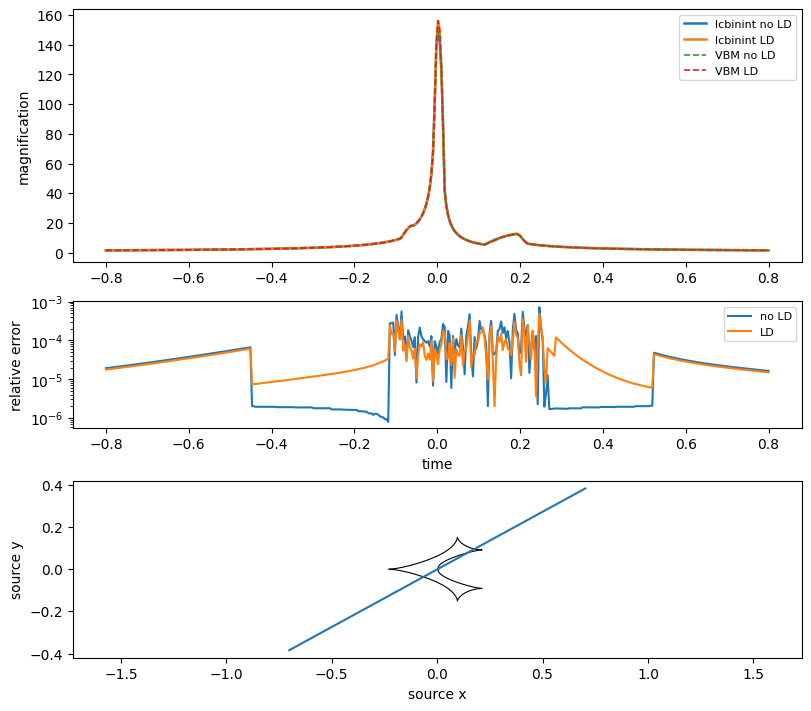

In [12]:
trajectory = lightcurve.source_trajectory(
    times,
    t0=case.t0,
    tE=case.tE,
    u0=case.u0,
    alpha=case.alpha,
    s=case.s,
    q=case.q,
)
caustics = lightcurve.caustics(s=case.s, q=case.q, n_points=900)

fig, (ax_mag, ax_res, ax_geo) = plt.subplots(
    3,
    1,
    figsize=(8, 7),
    gridspec_kw={"height_ratios": [2.0, 1.0, 1.4]},
    constrained_layout=True,
)
ax_mag.plot(times, lc_no_ld, label="lcbinint no LD", lw=1.8)
ax_mag.plot(times, lc_ld, label="lcbinint LD", lw=1.8)
if np.all(np.isfinite(vbm_no_ld)):
    ax_mag.plot(times, vbm_no_ld, "--", label="VBM no LD", lw=1.2)
    ax_mag.plot(times, vbm_ld, "--", label="VBM LD", lw=1.2)
ax_mag.set_ylabel("magnification")
ax_mag.legend(fontsize=8)

if np.all(np.isfinite(vbm_no_ld)):
    ax_res.semilogy(times, relative_error(vbm_no_ld, lc_no_ld), label="no LD")
    ax_res.semilogy(times, relative_error(vbm_ld, lc_ld), label="LD")
    ax_res.legend(fontsize=8)
else:
    ax_res.text(0.5, 0.5, "VBM is not installed", ha="center", va="center")
ax_res.set_ylabel("relative error")
ax_res.set_xlabel("time")

for xs, ys in zip(caustics.x, caustics.y):
    ax_geo.plot(xs, ys, color="black", lw=0.8)
ax_geo.plot(trajectory.x, trajectory.y, color="tab:blue", lw=1.5)
ax_geo.set_aspect("equal", adjustable="datalim")
ax_geo.set_xlabel("source x")
ax_geo.set_ylabel("source y")
plt.show()
